In [37]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, mean_squared_error, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from datetime import timedelta

In [38]:
# --- Load Datasets ---
df_2023 = pd.read_csv('/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2023.csv')
df_2024 = pd.read_csv('/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2024:2025.csv')
df = pd.concat([df_2023, df_2024], ignore_index=True)

# --- Datetime Parsing ---
df['Data'] = pd.to_datetime(df['Data'], format='mixed', dayfirst=True, errors='coerce')
df = df.dropna(subset=['Data'])
df['Datetime'] = df['Data'].dt.floor('H')

# --- Filter for Premuda Branch ---
df = df[df['Punto vendita'] == 'CAFEZAL_PREMUDA']

# --- Recompute Time Columns ---
df['Hour'] = df['Data'].dt.hour
df['Month'] = df['Data'].dt.month
df['Day'] = df['Data'].dt.day
df['Weekday'] = df['Data'].dt.day_name()

# --- Aggregate to Daily Sales ---
df['Date'] = df['Data'].dt.date
daily_df = df.groupby('Date').agg({
    'Totale': 'sum',
    'Hour': 'median',
    'Month': 'first',
    'Day': 'first',
    'Weekday': lambda x: x.mode()[0]
}).reset_index()

daily_df['Weekday_encoded'] = LabelEncoder().fit_transform(daily_df['Weekday'])


# --- Add Rolling Features ---
daily_df['RollingMean_7'] = daily_df['Totale'].rolling(window=7).mean().fillna(method='bfill')
daily_df['RollingStd_7'] = daily_df['Totale'].rolling(window=7).std().fillna(method='bfill')
daily_df['Lag_1'] = daily_df['Totale'].shift(1).fillna(method='bfill')

/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2445856287.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['Datetime'] = df['Data'].dt.floor('H')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2445856287.py:34: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df['RollingMean_7'] = daily_df['Totale'].rolling(window=7).mean().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2445856287.py:35: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df['RollingStd_7'] = daily_df['Totale'].rolling(window=7).std().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2445856287.py:36: FutureWarning: Series.fillna with 'method' is deprecated and will rai

In [39]:
# --- Define Features & Target ---
X = daily_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_7', 'RollingStd_7', 'Lag_1']]
y = daily_df['Totale']

In [40]:
# --- Cross-Validation (KFold Standard) ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')
print("Random Forest R² CV Scores:", cv_scores)
print("Average R²:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Random Forest R² CV Scores: [0.86802155 0.83202866 0.87186938 0.87047182 0.82001437]
Average R²: 0.8524811566754703
Standard Deviation: 0.021970288750336218


In [41]:
# --- Train Model ---
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=1000, n_jobs=-1, random_state=42)

In [42]:
# --- Predictions ---
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)


Random Forest Performance (Premuda - Daily Aggregated)
--------------------------------------------------------
Train R² Score: 0.9373
Train RMSE: 38.62
Train MAE: 30.22

Test R² Score: 0.4806
Test RMSE: 121.49
Test MAE: 87.84


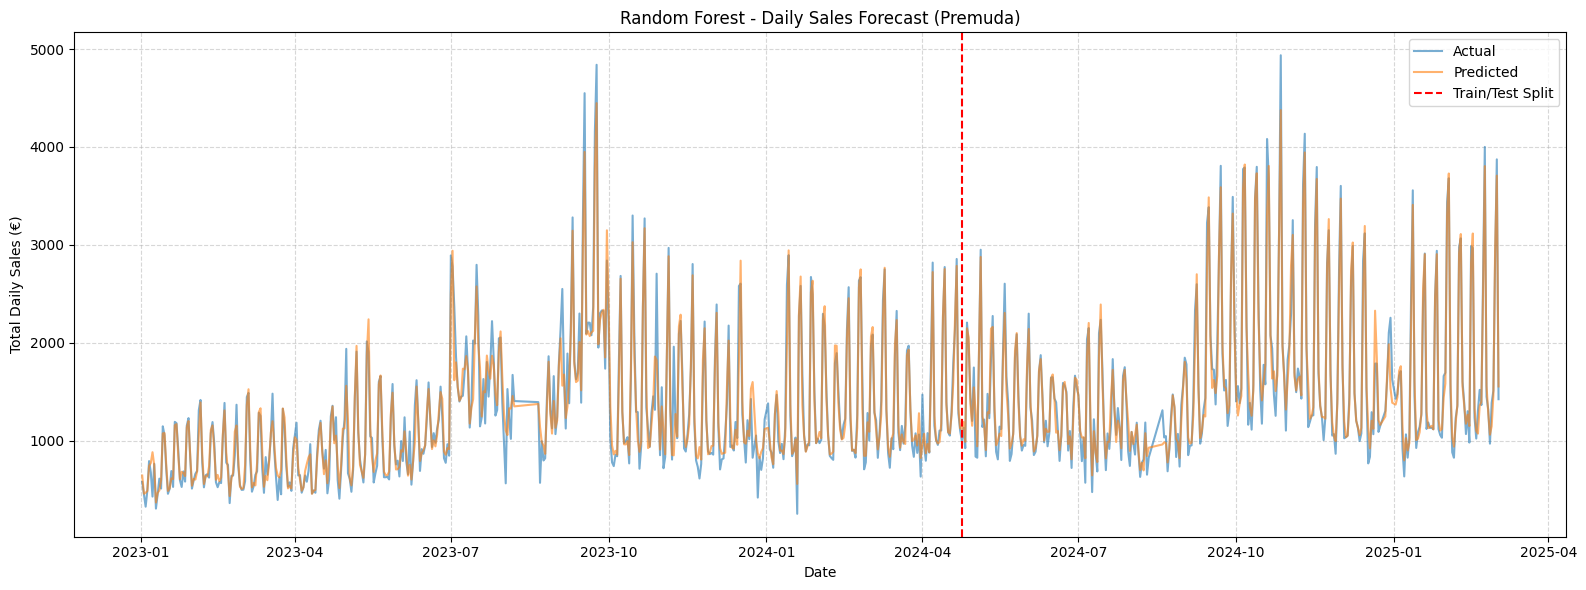

In [66]:
# --- Evaluation Metrics ---
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nRandom Forest Performance (Premuda - Daily Aggregated)")
print("--------------------------------------------------------")
print(f"Train R² Score: {r2_train:.4f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Train MAE: {mae_train:.2f}\n")
print(f"Test R² Score: {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test MAE: {mae_test:.2f}")

# --- Result DataFrame for Visualization ---
result_rf = pd.DataFrame()
result_rf['datetime'] = pd.to_datetime(daily_df['Date'])
result_rf['Actual'] = y.values
result_rf['Predicted'] = rf_model.predict(X)

# --- Visualization ---
plt.figure(figsize=(16, 6))
plt.plot(result_rf['datetime'], result_rf['Actual'], label='Actual', alpha=0.6)
plt.plot(result_rf['datetime'], result_rf['Predicted'], label='Predicted', alpha=0.6)
plt.axvline(x=result_rf.iloc[len(X_train)].datetime, color='red', linestyle='--', label='Train/Test Split')
plt.title('Random Forest - Daily Sales Forecast (Premuda)')
plt.xlabel('Date')
plt.ylabel('Total Daily Sales (€)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

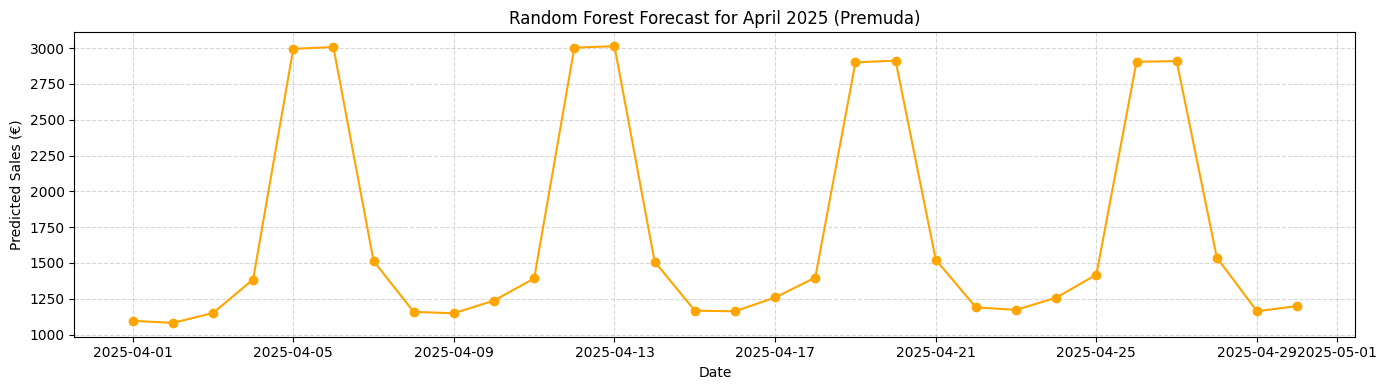

In [44]:
# =========================
# --- APRIL FORECASTING ---
# =========================
latest_month = daily_df['Date'].max()
april_dates = pd.date_range(start='2025-04-01', end='2025-04-30', freq='D')
april_df = pd.DataFrame({'Date': april_dates})
april_df['Hour'] = 12  # median hour
april_df['Day'] = april_df['Date'].dt.day
april_df['Month'] = april_df['Date'].dt.month
april_df['Weekday'] = april_df['Date'].dt.day_name()
april_df['Weekday_encoded'] = LabelEncoder().fit_transform(april_df['Weekday'])

april_df['RollingMean_7'] = daily_df['RollingMean_7'].iloc[-1]
april_df['RollingStd_7'] = daily_df['RollingStd_7'].iloc[-1]
april_df['Lag_1'] = daily_df['Totale'].iloc[-1]

X_april = april_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_7', 'RollingStd_7', 'Lag_1']]
april_df['Predicted_Sales'] = rf_model.predict(X_april)

plt.figure(figsize=(14, 4))
plt.plot(april_df['Date'], april_df['Predicted_Sales'], marker='o', color='orange')
plt.title('Random Forest Forecast for April 2025 (Premuda)')
plt.xlabel('Date')
plt.ylabel('Predicted Sales (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



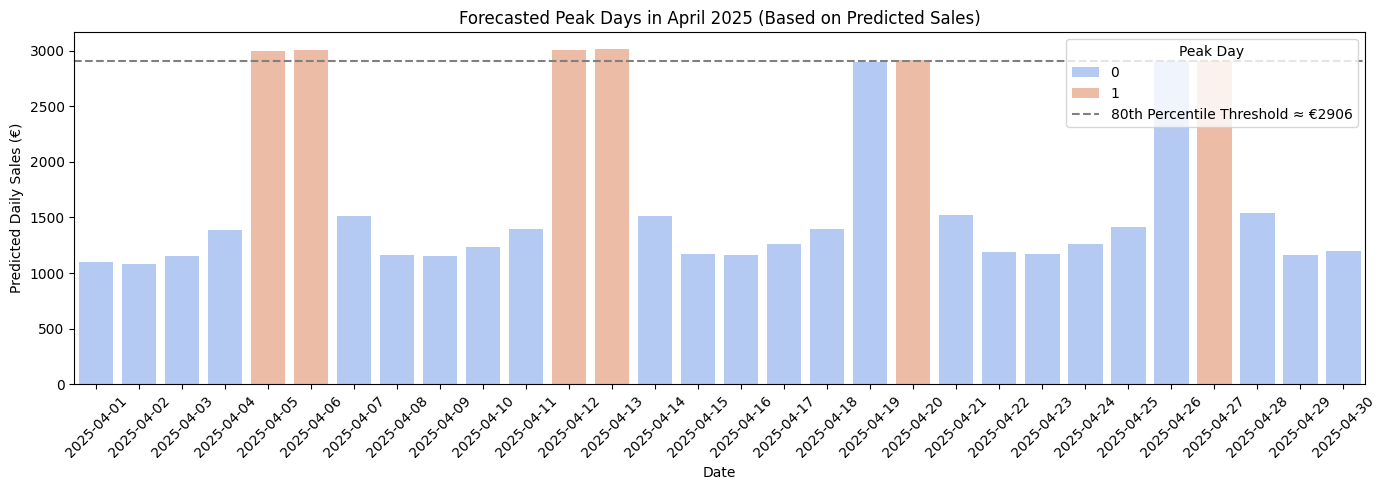


Identified Peak Days in April (Forecasted):
         Date  Predicted_Sales
4  2025-04-05       2995.56080
5  2025-04-06       3008.09516
11 2025-04-12       3003.67284
12 2025-04-13       3014.16467
19 2025-04-20       2912.85055
26 2025-04-27       2909.74034


In [45]:
# ==============================
# --- Peak Day Detection from Forecast ---
# ==============================

# Define peak threshold as top 20% of predicted April sales
peak_threshold = april_df['Predicted_Sales'].quantile(0.80)
april_df['Peak_Day'] = (april_df['Predicted_Sales'] >= peak_threshold).astype(int)

# Visualize predicted sales with peak labels
plt.figure(figsize=(14, 5))
sns.barplot(data=april_df, x='Date', y='Predicted_Sales', hue='Peak_Day', dodge=False, palette='coolwarm')
plt.axhline(peak_threshold, color='gray', linestyle='--', label=f'80th Percentile Threshold ≈ €{peak_threshold:.0f}')
plt.title('Forecasted Peak Days in April 2025 (Based on Predicted Sales)')
plt.xlabel('Date')
plt.ylabel('Predicted Daily Sales (€)')
plt.xticks(rotation=45)
plt.legend(title='Peak Day')
plt.tight_layout()
plt.show()

# Optional: Print top peak days
print("\nIdentified Peak Days in April (Forecasted):")
print(april_df[april_df['Peak_Day'] == 1][['Date', 'Predicted_Sales']])



✅ Daily Peak Classification Metrics (Improved Model)
-----------------------------------------------------
Train Accuracy: 0.9407665505226481
Train Precision: 0.7832167832167832
Train Recall: 0.9739130434782609
Train F1: 0.8682170542635659
Test Accuracy: 0.8697916666666666
Test Precision: 0.6346153846153846
Test Recall: 0.8461538461538461
Test F1: 0.7252747252747253
F1 Cross-Validation Scores: [0.77777778 0.85714286 0.79452055 0.68493151 0.7826087 ]
Average F1: 0.7793962770734659


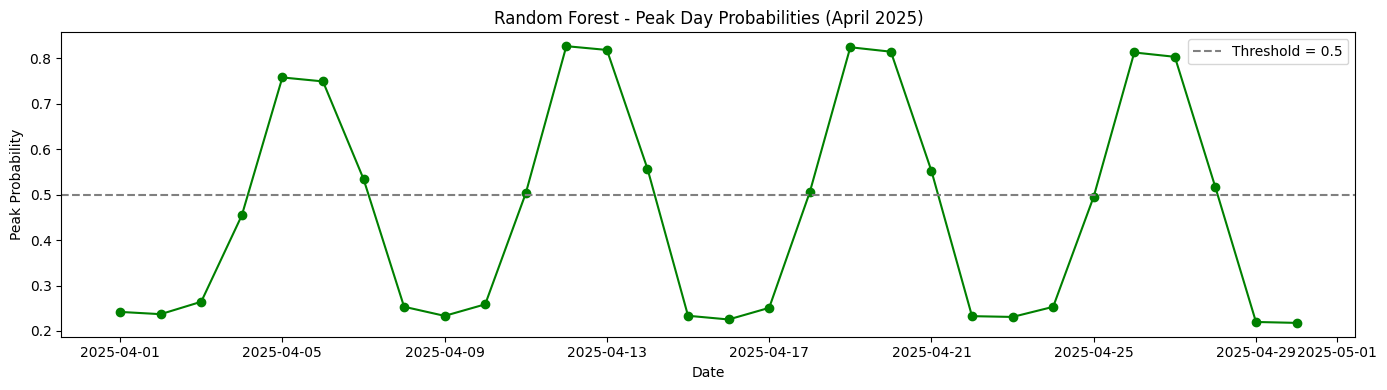


Top April Peak Days (Prob > 0.5):
         Date  Predicted_Sales  Peak_Prob
4  2025-04-05       2995.56080   0.757360
5  2025-04-06       3008.09516   0.748649
6  2025-04-07       1513.71805   0.534343
10 2025-04-11       1391.91795   0.502761
11 2025-04-12       3003.67284   0.826118
12 2025-04-13       3014.16467   0.817805
13 2025-04-14       1509.12284   0.556679
17 2025-04-18       1397.79840   0.504811
18 2025-04-19       2901.06511   0.823735
19 2025-04-20       2912.85055   0.813975
20 2025-04-21       1522.80847   0.551912
25 2025-04-26       2905.44768   0.812262
26 2025-04-27       2909.74034   0.802709
27 2025-04-28       1537.27572   0.515695


In [46]:
from sklearn.model_selection import StratifiedKFold

# ==============================
# --- PEAK DAY CLASSIFICATION ---
# ==============================

# Create binary label based on top 20% of historical sales
thresh = daily_df['Totale'].quantile(0.80)
daily_df['Peak_Day'] = (daily_df['Totale'] >= thresh).astype(int)

X_class = daily_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_7', 'RollingStd_7', 'Lag_1']]
y_class = daily_df['Peak_Day']

# --- Train/Test Split ---
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.25, random_state=42, stratify=y_class
)

# --- Define Optimized Random Forest Classifier ---
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
clf.fit(Xc_train, yc_train)

# --- Predictions & Evaluation ---
y_train_pred = clf.predict(Xc_train)
y_test_pred = clf.predict(Xc_test)

print("\n✅ Daily Peak Classification Metrics (Improved Model)")
print("-----------------------------------------------------")
print("Train Accuracy:", accuracy_score(yc_train, y_train_pred))
print("Train Precision:", precision_score(yc_train, y_train_pred))
print("Train Recall:", recall_score(yc_train, y_train_pred))
print("Train F1:", f1_score(yc_train, y_train_pred))
print("Test Accuracy:", accuracy_score(yc_test, y_test_pred))
print("Test Precision:", precision_score(yc_test, y_test_pred))
print("Test Recall:", recall_score(yc_test, y_test_pred))
print("Test F1:", f1_score(yc_test, y_test_pred))

# --- Stratified Cross-Validation for Robust F1 ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_peak_scores = cross_val_score(clf, X_class, y_class, cv=skf, scoring='f1')
print("F1 Cross-Validation Scores:", cv_peak_scores)
print("Average F1:", np.mean(cv_peak_scores))

# --- Final Model for April Forecasting ---
rf_clf = clf  # Reuse trained classifier
april_df['Peak_Prob'] = rf_clf.predict_proba(X_april)[:, 1]

# --- Visualization ---
plt.figure(figsize=(14, 4))
plt.plot(april_df['Date'], april_df['Peak_Prob'], marker='o', color='green')
plt.axhline(0.5, linestyle='--', color='gray', label='Threshold = 0.5')
plt.title('Random Forest - Peak Day Probabilities (April 2025)')
plt.xlabel('Date')
plt.ylabel('Peak Probability')
plt.legend()
plt.tight_layout()
plt.show()

# --- Output Peak Days Based on Probability ---
print("\nTop April Peak Days (Prob > 0.5):")
print(april_df[april_df['Peak_Prob'] > 0.5][['Date', 'Predicted_Sales', 'Peak_Prob']])


In [47]:
# ==============================
# --- MERGE WEATHER DATA ---
# ==============================

# Load weather dataset
weather = pd.read_csv('/Users/alexanderdagher/Documents/CafeZal/forcasting_model/milan 2024-04-01 to 2025-04-01.csv')

# Parse date
weather['datetime'] = pd.to_datetime(weather['datetime'])
weather['Date'] = weather['datetime'].dt.date

# Select only important columns
weather = weather[['Date', 'temp', 'humidity', 'precip', 'windspeed', 'conditions']]

# Optional: Encode weather "conditions" (like Rain, Clear, Cloudy)
weather['conditions_encoded'] = LabelEncoder().fit_transform(weather['conditions'])

# Merge with daily sales dataframe
daily_df['Date'] = pd.to_datetime(daily_df['Date'])  # ensure same format
weather['Date'] = pd.to_datetime(weather['Date'])

daily_df = pd.merge(daily_df, weather, on='Date', how='left')

# --- Fill missing weather data if any ---
daily_df[['temp', 'humidity', 'precip', 'windspeed']] = daily_df[['temp', 'humidity', 'precip', 'windspeed']].fillna(method='ffill')
daily_df['conditions_encoded'] = daily_df['conditions_encoded'].fillna(method='ffill')

# --- Updated Features for Modeling ---
X = daily_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_7', 'RollingStd_7', 'Lag_1',
              'temp', 'humidity', 'precip', 'windspeed', 'conditions_encoded']]
y = daily_df['Totale']

print("✅ Weather data merged! Features now available:", X.columns.tolist())


✅ Weather data merged! Features now available: ['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_7', 'RollingStd_7', 'Lag_1', 'temp', 'humidity', 'precip', 'windspeed', 'conditions_encoded']


/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/839847091.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df[['temp', 'humidity', 'precip', 'windspeed']] = daily_df[['temp', 'humidity', 'precip', 'windspeed']].fillna(method='ffill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/839847091.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df['conditions_encoded'] = daily_df['conditions_encoded'].fillna(method='ffill')


In [48]:
# ==============================
# --- RETRAIN RANDOM FOREST WITH WEATHER ---
# ==============================

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- Define Updated X and y Again (after weather merge) ---
X = daily_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_7', 'RollingStd_7', 'Lag_1',
              'temp', 'humidity', 'precip', 'windspeed', 'conditions_encoded']]
y = daily_df['Totale']

# --- Cross-Validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='r2')

print("\n✅ Cross-Validation Results with Weather Features:")
print("R² CV Scores:", cv_scores)
print("Average R²:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# --- Train Random Forest ---
rf_model = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# --- Predictions ---
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# --- Evaluation Metrics ---
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n✅ Random Forest Performance (With Weather Data)")
print("------------------------------------------------")
print(f"Train R² Score: {r2_train:.4f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Train MAE: {mae_train:.2f}\n")
print(f"Test R² Score: {r2_test:.4f}")
print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test MAE: {mae_test:.2f}")



✅ Cross-Validation Results with Weather Features:
R² CV Scores: [0.86420432 0.83682332 0.8681238  0.86559767 0.82230853]
Average R²: 0.8514115251956781
Standard Deviation: 0.018460782684546352

✅ Random Forest Performance (With Weather Data)
------------------------------------------------
Train R² Score: 0.9781
Train RMSE: 110.48
Train MAE: 79.94

Test R² Score: 0.8622
Test RMSE: 284.82
Test MAE: 204.82


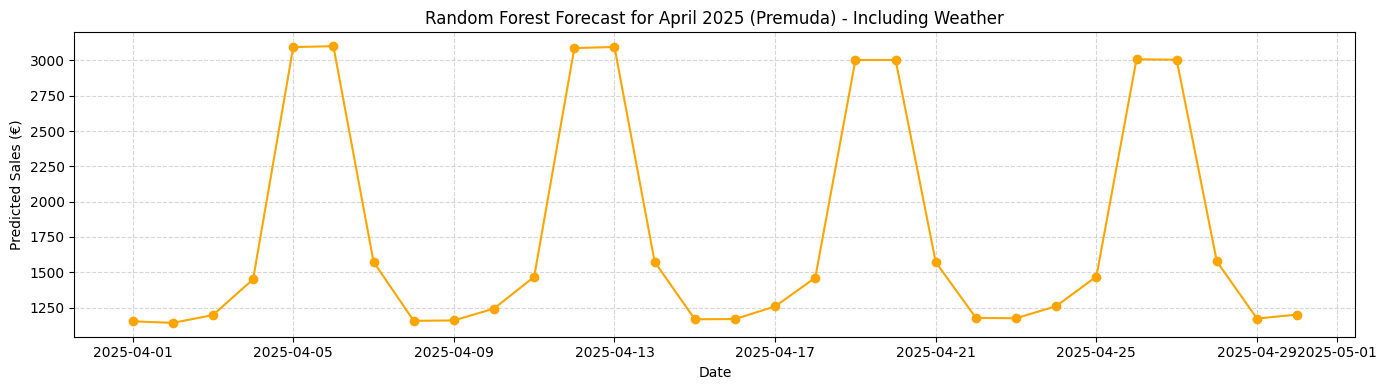


✅ Full April 2025 Sales Predictions:
      Date  Predicted_Sales
2025-04-01       1152.64488
2025-04-02       1141.50474
2025-04-03       1196.98646
2025-04-04       1450.36001
2025-04-05       3094.49328
2025-04-06       3101.06482
2025-04-07       1573.53926
2025-04-08       1156.05141
2025-04-09       1158.70109
2025-04-10       1243.00137
2025-04-11       1467.47739
2025-04-12       3087.58416
2025-04-13       3095.24925
2025-04-14       1573.84902
2025-04-15       1166.98040
2025-04-16       1168.51294
2025-04-17       1258.24842
2025-04-18       1461.45786
2025-04-19       3003.03381
2025-04-20       3003.52949
2025-04-21       1571.61839
2025-04-22       1176.92083
2025-04-23       1174.13947
2025-04-24       1259.92146
2025-04-25       1469.51072
2025-04-26       3008.12090
2025-04-27       3004.85723
2025-04-28       1576.26464
2025-04-29       1172.41171
2025-04-30       1200.06941


In [49]:
# =========================
# --- APRIL FORECASTING (With Weather) ---
# =========================

# 1. Generate April dates
april_dates = pd.date_range(start='2025-04-01', end='2025-04-30', freq='D')
april_df = pd.DataFrame({'Date': april_dates})

# 2. Build April features
april_df['Hour'] = 12  # Median hour assumption
april_df['Day'] = april_df['Date'].dt.day
april_df['Month'] = april_df['Date'].dt.month
april_df['Weekday'] = april_df['Date'].dt.day_name()
april_df['Weekday_encoded'] = LabelEncoder().fit_transform(april_df['Weekday'])

# 3. Copy Rolling and Weather Features from Last Known Day
april_df['RollingMean_7'] = daily_df['RollingMean_7'].iloc[-1]
april_df['RollingStd_7'] = daily_df['RollingStd_7'].iloc[-1]
april_df['Lag_1'] = daily_df['Totale'].iloc[-1]

april_df['temp'] = daily_df['temp'].iloc[-1]
april_df['humidity'] = daily_df['humidity'].iloc[-1]
april_df['precip'] = daily_df['precip'].iloc[-1]
april_df['windspeed'] = daily_df['windspeed'].iloc[-1]
april_df['conditions_encoded'] = daily_df['conditions_encoded'].iloc[-1]

# 4. Prepare April Feature Set
X_april = april_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 
                    'RollingMean_7', 'RollingStd_7', 'Lag_1', 
                    'temp', 'humidity', 'precip', 'windspeed', 'conditions_encoded']]

# 5. Predict April Sales
april_df['Predicted_Sales'] = rf_model.predict(X_april)

# 6. Visualization
plt.figure(figsize=(14, 4))
plt.plot(april_df['Date'], april_df['Predicted_Sales'], marker='o', color='orange')
plt.title('Random Forest Forecast for April 2025 (Premuda) - Including Weather')
plt.xlabel('Date')
plt.ylabel('Predicted Sales (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 7. Output Full Forecast List
print("\n✅ Full April 2025 Sales Predictions:")
print(april_df[['Date', 'Predicted_Sales']].to_string(index=False))


In [58]:
# Load datasets fresh
df_2023 = pd.read_csv('/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2023.csv')
df_2024 = pd.read_csv('/Users/alexanderdagher/Documents/CafeZal/Coffee-Sales-EDA-and-Prediction-main/mother_data - 2024:2025.csv')
df = pd.concat([df_2023, df_2024], ignore_index=True)

# Datetime parsing
df['Data'] = pd.to_datetime(df['Data'], format='mixed', dayfirst=True, errors='coerce')
df = df.dropna(subset=['Data'])
df['Datetime'] = df['Data'].dt.floor('H')

branches = [
    'CAFEZAL_PREMUDA',
    'CAFEZAL_SOLFERINO',
    'CAFEZAL_S_GREGORIO',
    'CAFEZAL_CSO_MAGENTA'
]



/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/1910786856.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['Datetime'] = df['Data'].dt.floor('H')


In [65]:
import os

# ==============================
# --- Forecasting for All Branches + Saving ---
# ==============================

# Create folders if they don't exist
os.makedirs('April_Forecasts', exist_ok=True)
os.makedirs('April_Forecast_Plots', exist_ok=True)

# Storage for results
all_branch_metrics = []
all_branch_forecasts = {}

# Loop over each branch
for branch in branches:
    print(f"\n🌟 Forecasting for Branch: {branch}")

    branch_df = df[df['Punto vendita'] == branch].copy()

    # Recompute time columns (they are missing after fresh loading)
    branch_df['Hour'] = branch_df['Data'].dt.hour
    branch_df['Month'] = branch_df['Data'].dt.month
    branch_df['Day'] = branch_df['Data'].dt.day
    branch_df['Weekday'] = branch_df['Data'].dt.day_name()


    # (then same processing as Premuda: feature engineering, weather merge, etc.)


    # 1. Filter data for the branch (already done above)

    if len(branch_df) < 30:
        print("⚠️ Skipping (not enough data)")
        continue


    # 2. Aggregate daily sales
    branch_df['Date'] = branch_df['Data'].dt.date
    daily_df_branch = branch_df.groupby('Date').agg({
        'Totale': 'sum',
        'Hour': 'median',
        'Month': 'first',
        'Day': 'first',
        'Weekday': lambda x: x.mode()[0]
    }).reset_index()

    # Time features
    daily_df_branch['Weekday_encoded'] = LabelEncoder().fit_transform(daily_df_branch['Weekday'])

    # 3. Rolling features
    daily_df_branch['RollingMean_7'] = daily_df_branch['Totale'].rolling(window=7).mean().fillna(method='bfill')
    daily_df_branch['RollingStd_7'] = daily_df_branch['Totale'].rolling(window=7).std().fillna(method='bfill')
    daily_df_branch['Lag_1'] = daily_df_branch['Totale'].shift(1).fillna(method='bfill')

    # 4. Merge weather
    daily_df_branch['Date'] = pd.to_datetime(daily_df_branch['Date'])
    merged_df = pd.merge(daily_df_branch, weather, on='Date', how='left')
    merged_df[['temp', 'humidity', 'precip', 'windspeed']] = merged_df[['temp', 'humidity', 'precip', 'windspeed']].fillna(method='ffill')
    merged_df['conditions_encoded'] = merged_df['conditions_encoded'].fillna(method='ffill')

    # 5. Features and Target
    X_branch = merged_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_7', 'RollingStd_7', 'Lag_1',
                          'temp', 'humidity', 'precip', 'windspeed', 'conditions_encoded']]
    y_branch = merged_df['Totale']

    # 6. Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_branch, y_branch, test_size=0.25, random_state=42)

    # 7. Model
    rf_model_branch = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
    rf_model_branch.fit(X_train, y_train)

    # 8. Metrics
    y_pred_train = rf_model_branch.predict(X_train)
    y_pred_test = rf_model_branch.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    print(f"Train R² Score: {r2_train:.4f} | RMSE: {rmse_train:.2f}")
    print(f"Test  R² Score: {r2_test:.4f} | RMSE: {rmse_test:.2f}")

    all_branch_metrics.append({
        'Branch': branch,
        'Train_R2': r2_train,
        'Train_RMSE': rmse_train,
        'Test_R2': r2_test,
        'Test_RMSE': rmse_test
    })

    # 9. April Forecast
    april_dates = pd.date_range(start='2025-04-01', end='2025-04-30', freq='D')
    april_df = pd.DataFrame({'Date': april_dates})
    april_df['Hour'] = 12
    april_df['Day'] = april_df['Date'].dt.day
    april_df['Month'] = april_df['Date'].dt.month
    april_df['Weekday'] = april_df['Date'].dt.day_name()
    april_df['Weekday_encoded'] = LabelEncoder().fit_transform(april_df['Weekday'])

    # Carry latest weather stats
    april_df['temp'] = merged_df['temp'].iloc[-1]
    april_df['humidity'] = merged_df['humidity'].iloc[-1]
    april_df['precip'] = merged_df['precip'].iloc[-1]
    april_df['windspeed'] = merged_df['windspeed'].iloc[-1]
    april_df['conditions_encoded'] = merged_df['conditions_encoded'].iloc[-1]

    # Carry latest rolling features
    april_df['RollingMean_7'] = merged_df['RollingMean_7'].iloc[-1]
    april_df['RollingStd_7'] = merged_df['RollingStd_7'].iloc[-1]
    april_df['Lag_1'] = merged_df['Lag_1'].iloc[-1]

    # Predict
    X_april = april_df[['Hour', 'Day', 'Month', 'Weekday_encoded', 'RollingMean_7', 'RollingStd_7', 'Lag_1',
                        'temp', 'humidity', 'precip', 'windspeed', 'conditions_encoded']]
    april_df['Predicted_Sales'] = rf_model_branch.predict(X_april)

    all_branch_forecasts[branch] = april_df

    # Save forecast CSV
    safe_branch = branch.replace("/", "-").replace("\\", "-")
    april_df.to_csv(f'April_Forecasts/{safe_branch}_AprilForecast.csv', index=False)

    # Save forecast plot
    plt.figure(figsize=(14, 5))
    plt.plot(april_df['Date'], april_df['Predicted_Sales'], marker='o')
    plt.title(f'April 2025 Forecast - {branch}')
    plt.xlabel('Date')
    plt.ylabel('Predicted Sales (€)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'April_Forecast_Plots/{safe_branch}_AprilForecast.png')
    plt.close()

    # --- Create Full Actual vs Predicted Series ---
    full_actual = np.concatenate([y_train, y_test])
    full_predicted = np.concatenate([y_pred_train, y_pred_test])

    # Rebuild full date index
    full_dates = pd.concat([X_train.assign(Target=y_train), X_test.assign(Target=y_test)])
    full_dates = full_dates.sort_index()  # sort by date

    result_df = pd.DataFrame()
    result_df['datetime'] = merged_df['Date'].iloc[full_dates.index]  # REAL DATES based on original data
    result_df['Actual'] = full_dates['Target'].values
    result_df['Predicted'] = np.concatenate([y_pred_train, y_pred_test])

    # --- Plot ---
    plt.figure(figsize=(16, 6))
    plt.plot(result_df['datetime'], result_df['Actual'], label='Actual', alpha=0.6)
    plt.plot(result_df['datetime'], result_df['Predicted'], label='Predicted', alpha=0.6)
    plt.axvline(x=result_df['datetime'].iloc[len(X_train)], color='red', linestyle='--', label='Train/Test Split')
    plt.title(f'Random Forest - Daily Sales Forecast ({branch})')
    plt.xlabel('Date')
    plt.ylabel('Total Daily Sales (€)')
    plt.xticks(rotation=45)  # Rotate dates for better reading
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'April_Forecast_Plots/{branch.replace("/", "-")}_TrainTest_Performance.png')
    plt.close()




# ===================
# --- Final Outputs ---
# ===================

# Metrics Table
metrics_df = pd.DataFrame(all_branch_metrics)
metrics_df.to_csv('April_Forecasts/Branch_Performance_Metrics.csv', index=False)

print("\n📋 Final Branch Metrics saved!")
print(metrics_df)



🌟 Forecasting for Branch: CAFEZAL_PREMUDA


/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['RollingMean_7'] = daily_df_branch['Totale'].rolling(window=7).mean().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['RollingStd_7'] = daily_df_branch['Totale'].rolling(window=7).std().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['Lag_1'] = daily_df_branch['Totale'].shift(1).fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000g

Train R² Score: 0.9781 | RMSE: 110.48
Test  R² Score: 0.8622 | RMSE: 284.82

🌟 Forecasting for Branch: CAFEZAL_SOLFERINO


/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['RollingMean_7'] = daily_df_branch['Totale'].rolling(window=7).mean().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['RollingStd_7'] = daily_df_branch['Totale'].rolling(window=7).std().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['Lag_1'] = daily_df_branch['Totale'].shift(1).fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000g

Train R² Score: 0.9732 | RMSE: 79.43
Test  R² Score: 0.7940 | RMSE: 211.46

🌟 Forecasting for Branch: CAFEZAL_S_GREGORIO


/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['RollingMean_7'] = daily_df_branch['Totale'].rolling(window=7).mean().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['RollingStd_7'] = daily_df_branch['Totale'].rolling(window=7).std().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['Lag_1'] = daily_df_branch['Totale'].shift(1).fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000g

Train R² Score: 0.9470 | RMSE: 43.77
Test  R² Score: 0.5887 | RMSE: 164.11

🌟 Forecasting for Branch: CAFEZAL_CSO_MAGENTA


/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:52: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['RollingMean_7'] = daily_df_branch['Totale'].rolling(window=7).mean().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:53: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['RollingStd_7'] = daily_df_branch['Totale'].rolling(window=7).std().fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000gn/T/ipykernel_20008/2041738302.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  daily_df_branch['Lag_1'] = daily_df_branch['Totale'].shift(1).fillna(method='bfill')
/var/folders/b0/hvkkd_2d5117jzw6wr3mkw2w0000g

Train R² Score: 0.9373 | RMSE: 38.62
Test  R² Score: 0.4806 | RMSE: 121.49

📋 Final Branch Metrics saved!
                Branch  Train_R2  Train_RMSE   Test_R2   Test_RMSE
0      CAFEZAL_PREMUDA  0.978106  110.484602  0.862179  284.821195
1    CAFEZAL_SOLFERINO  0.973158   79.430187  0.793965  211.457880
2   CAFEZAL_S_GREGORIO  0.946953   43.774756  0.588664  164.112314
3  CAFEZAL_CSO_MAGENTA  0.937262   38.618550  0.480581  121.493013
